## Bước 0 – Import thư viện

In [97]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate

# Dùng librosa để đọc WAV trong Colab.
import librosa

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.max_columns', 50)

## Bước 1 – Khai báo đường dẫn dữ liệu local

In [98]:
from pathlib import Path

PROJECT_DIR = Path(os.environ.get('BT2_PROJECT_DIR', Path.cwd())).expanduser().resolve()
TRAIN_DIR = str(PROJECT_DIR / 'TinHieuHuanLuyen')
TEST_DIR = str(PROJECT_DIR / 'TinHieuKiemThu')
TRAIN_SUFFIX = None
TEST_SUFFIX = None
if not os.path.isdir(TRAIN_DIR) or not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f'Không tìm thấy hai thư mục WAV/LAB trong {PROJECT_DIR}')

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TRAIN_DIR: /content/drive/MyDrive/Seventh Semester/Spoken Language Processing/BT2/TinHieuHuanLuyen
TEST_DIR : /content/drive/MyDrive/Seventh Semester/Spoken Language Processing/BT2/TinHieuKiemThu


## Bước 2 – Khai báo tham số dùng chung

In [99]:
HOP_MS = 10

# Khảo sát 20 ms, 25 ms và 30 ms (25 ms được bổ sung sau).
FRAME_CANDIDATES_MS = [20, 25, 30]

# Dải F0 người trưởng thành theo đề bài.
F0_MIN = 70
F0_MAX = 400

EPS = 1e-12

# Tham số cho histogram-based threshold phỏng theo [5].
# [5] dùng histogram của feature, làm trơn, tìm 2 local maxima M1/M2,
# rồi T = (W*M1 + M2)/(W+1). Ở đây feature là periodicity score ACF.
HIST_BINS = 20
HIST_SMOOTH_WINDOW = 5
HIST_W = 1.0

## Bước 3 – Hàm đọc WAV và LAB

In [100]:
def load_wav(path):
    """Đọc WAV, giữ nguyên sample rate và chuyển về mono float."""
    y, sr = librosa.load(path, sr=None, mono=True)
    return int(sr), y.astype(np.float64)


def parse_lab_file(file_path, verbose=False):
    """
    Đọc file .lab:
      start  end  label
      ...
      F0mean value
      F0std  value
    """
    segments = []
    f0_mean = None
    f0_std = None

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            if parts[0] == 'F0mean':
                f0_mean = float(parts[1])
            elif parts[0] == 'F0std':
                f0_std = float(parts[1])
            else:
                segments.append({
                    'start': float(parts[0]),
                    'end': float(parts[1]),
                    'label': parts[2].lower()
                })

    if verbose:
        print(
            f"[LAB] {os.path.basename(file_path)}: "
            f"{len(segments)} segments, F0mean={f0_mean}, F0std={f0_std}"
        )

    return segments, f0_mean, f0_std


def get_lab_path(wav_path):
    """Tìm file .lab tương ứng; hỗ trợ .lab.bin khi notebook được kiểm thử cục bộ."""
    stem = os.path.splitext(wav_path)[0]
    candidates = [stem + '.lab', stem + '.lab.bin']
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Không tìm thấy LAB cho {wav_path}")


def list_wav_files(directory, suffix=None):
    files = sorted(glob.glob(os.path.join(directory, '*.wav')))
    if suffix is not None:
        files = [
            f for f in files
            if os.path.splitext(os.path.basename(f))[0].endswith(suffix)
        ]
    return files


train_wavs = list_wav_files(TRAIN_DIR, TRAIN_SUFFIX)
test_wavs = list_wav_files(TEST_DIR, TEST_SUFFIX)

print("Training WAV:")
for p in train_wavs:
    print(" -", os.path.basename(p))

print("\nTesting WAV:")
for p in test_wavs:
    print(" -", os.path.basename(p))

assert len(test_wavs) == 4, f"Đề bài yêu cầu 4 file test, hiện tìm thấy {len(test_wavs)}."

Training WAV:
 - phone_F1.wav
 - phone_M1.wav
 - studio_F1.wav
 - studio_M1.wav

Testing WAV:
 - phone_F2.wav
 - phone_M2.wav
 - studio_F2.wav
 - studio_M2.wav



## Bước 4 – Chia khung và ánh xạ frame → nhãn LAB

Mỗi frame được gán nhãn theo **thời điểm tâm khung**. Cách này tránh phải quyết định theo toàn bộ khoảng chồng lấn khi frame nằm gần biên segment.


In [101]:
def framing(signal, fs, frame_ms=30, hop_ms=10):
    frame_len = int(round(fs * frame_ms / 1000.0))
    hop_len = int(round(fs * hop_ms / 1000.0))

    if len(signal) < frame_len:
        return np.empty((0, frame_len)), np.array([])

    starts = np.arange(0, len(signal) - frame_len + 1, hop_len)
    frames = np.stack([signal[s:s + frame_len] for s in starts])
    center_times = (starts + frame_len / 2.0) / fs

    return frames, center_times


def label_at_time(t, segments):
    for seg in segments:
        if seg['start'] <= t < seg['end']:
            return seg['label']
    return None


## Bước 5 – Normalized ACF

Với lag (k), ACF chuẩn hóa được dùng ở đây là:

$$
\rho(k)=
\frac{\sum_{n=0}^{N-1-k}x[n]x[n+k]}
{\sqrt{\sum_{n=0}^{N-1-k}x[n]^2}
 \sqrt{\sum_{n=0}^{N-1-k}x[n+k]^2}}
$$

Trước khi tính ACF, frame được trừ mean để giảm ảnh hưởng DC.

Khác với chỉ chia mọi lag cho $R(0)$, cách chuẩn hóa này tính năng lượng đúng trên **phần tín hiệu chồng nhau tại từng lag**, nên score của các lag khác nhau có thể so sánh hợp lý hơn.


In [102]:
def normalized_acf(frame):
    x = np.asarray(frame, dtype=np.float64)
    x = x - np.mean(x)
    n = len(x)

    if n == 0:
        return np.array([])

    # Numerator ACF cho các lag >= 0.
    # FFT correlation giúp quét toàn bộ lag nhanh hơn loop Python.
    numerator = correlate(x, x, mode='full', method='fft')[n - 1:]

    # Vector hóa mẫu số theo đúng vùng overlap của từng lag.
    sq = x * x
    csum = np.concatenate(([0.0], np.cumsum(sq)))
    lags = np.arange(n)

    energy_left = csum[n - lags]       # sum x[0 : n-k]^2
    energy_right = csum[n] - csum[lags]  # sum x[k : n]^2
    denominator = np.sqrt(energy_left * energy_right)

    acf = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator, dtype=np.float64),
        where=denominator > EPS
    )

    return acf

## Minh họa

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets

# 1. Tạo một đoạn sóng âm có tính tuần hoàn (giả lập nguyên âm Voiced)
fs = 8000
t = np.linspace(0, 0.02, int(fs * 0.02)) # Khung dài 20ms
f0_true = 150 # Tần số lặp lại là 150Hz (Chu kỳ = 8000/150 = ~53 mẫu)

# Tạo hình dáng sóng lặp đi lặp lại
y = np.sin(2 * np.pi * f0_true * t) + 0.4 * np.sin(2 * np.pi * 2 * f0_true * t)

# Tính sẵn ACF chuẩn hóa để vẽ đồ thị dưới
acf = np.correlate(y, y, mode='full')[len(y)-1:]
acf = acf / acf[0]

def animate_acf(k):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

    # --- Trục 1: Tín hiệu gốc và bản sao trượt đi k ---
    ax1.plot(y, label='Bản gốc (Đứng im)', color='blue', linewidth=3, alpha=0.4)

    # Vẽ bản sao (chỉ phần giao nhau bắt đầu từ k)
    if k < len(y):
        ax1.plot(range(k, len(y)), y[:-k] if k > 0 else y,
                 label=f'Bản sao (Trượt k={k})', color='red', linestyle='--', linewidth=2)

        # Tô màu phần đè lên nhau (vùng overlap đang được tính điểm)
        ax1.fill_between(range(k, len(y)), y[k:], (y[:-k] if k > 0 else y),
                         color='purple', alpha=0.15, label='Phần đè lên nhau')

    ax1.set_xlim(0, len(y))
    ax1.set_ylim(-1.8, 1.8)
    ax1.set_title(f"Quá trình trượt bản sao (Lag k = {k} mẫu)")
    ax1.legend(loc='upper right')
    ax1.set_xticks([])

    # --- Trục 2: Biểu đồ điểm ACF tương ứng ---
    ax2.plot(acf, color='green', label='Đường cong điểm ACF')
    ax2.scatter(k, acf[k], color='red', s=120, zorder=5) # Chấm đỏ chạy theo k
    ax2.axvline(k, color='red', linestyle=':', alpha=0.5)

    # Đánh dấu đỉnh hoàn hảo thứ 2 (Chu kỳ âm thanh)
    best_lag = int(fs / f0_true)
    ax2.axvline(best_lag, color='orange', linestyle='--', label=f'Chu kỳ thực (k={best_lag})')

    ax2.set_xlim(0, len(y))
    ax2.set_ylim(-1.1, 1.1)
    ax2.set_title("Điểm số so khớp (Khớp hoàn hảo = 1.0)")
    ax2.legend(loc='upper right')
    ax2.set_xlabel("Số mẫu trượt đi (Lag k)")

    plt.tight_layout()
    plt.show()

print("KÉO THANH TRƯỢT 'k' BÊN DƯỚI ĐỂ XEM QUÁ TRÌNH ACF!")
interact(animate_acf, k=widgets.IntSlider(min=0, max=len(y)-10, step=1, value=0));

KÉO THANH TRƯỢT 'k' BÊN DƯỚI ĐỂ XEM QUÁ TRÌNH ACF!


interactive(children=(IntSlider(value=0, description='k', max=150), Output()), _dom_classes=('widget-interact'…

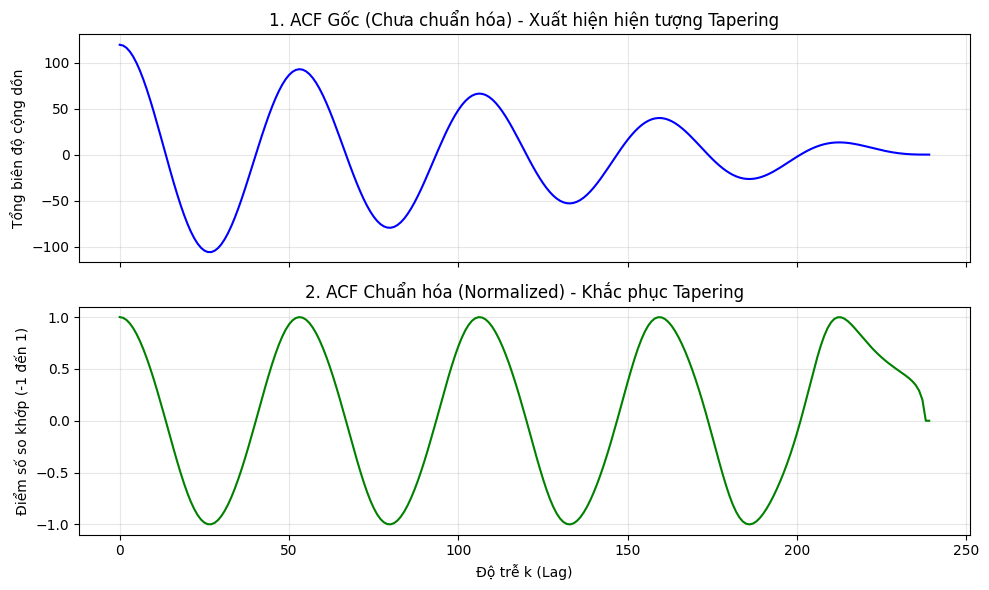

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Tạo một sóng âm tuần hoàn hoàn hảo (150Hz, dài 30ms)
fs = 8000
t = np.linspace(0, 0.03, int(fs * 0.03))
N = len(t)
# Tín hiệu lặp lại hoàn hảo, biên độ không đổi
x = np.sin(2 * np.pi * 150 * t)

# 2. Tính ACF Gốc (Chưa chuẩn hóa)
acf_unnormalized = np.zeros(N)
for k in range(N):
    # Chỉ cộng dồn phần giao nhau: từ 0 đến N-1-k
    acf_unnormalized[k] = np.sum(x[0:N-k] * x[k:N])

# 3. Tính ACF Chuẩn hóa (Chia cho năng lượng phần giao nhau)
acf_normalized = np.zeros(N)
for k in range(N):
    energy_left = np.sum(x[0:N-k]**2)
    energy_right = np.sum(x[k:N]**2)
    if energy_left * energy_right > 0:
        acf_normalized[k] = acf_unnormalized[k] / np.sqrt(energy_left * energy_right)

# 4. Vẽ đồ thị so sánh
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Đồ thị ACF Gốc
ax1.plot(acf_unnormalized, color='blue')
ax1.set_title("1. ACF Gốc (Chưa chuẩn hóa) - Xuất hiện hiện tượng Tapering")
ax1.set_ylabel("Tổng biên độ cộng dồn")
ax1.grid(True, alpha=0.3)

# Đồ thị ACF Chuẩn hóa
ax2.plot(acf_normalized, color='green')
ax2.set_title("2. ACF Chuẩn hóa (Normalized) - Khắc phục Tapering")
ax2.set_xlabel("Độ trễ k (Lag)")
ax2.set_ylabel("Điểm số so khớp (-1 đến 1)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Bước 6 – Highest local peak, best lag và F0

Chỉ tìm peak trong vùng:

$$k_{\min}=\left\lceil\frac{f_s}{F0_{\max}}\right\rceil,\qquad k_{\max}=\left\lfloor\frac{f_s}{F0_{\min}}\right\rfloor$$

với $70 \le F0 \le 400$ Hz.

- `periodicity_score` = biên độ **highest local peak** của normalized ACF.
- `best_lag` = vị trí peak đó.
- Với frame được xác định là voiced:

$$F0 = \frac{f_s}{best_lag}$$

Notebook nội suy parabol quanh peak để có `best_lag` phân số, giúp F0 ít bị lượng tử hóa theo sample.

In [105]:
def detect_pitch_acf(frame, fs, f0_min=F0_MIN, f0_max=F0_MAX):
    acf = normalized_acf(frame)

    lag_min = max(1, int(np.ceil(fs / f0_max)))
    lag_max = min(len(frame) - 2, int(np.floor(fs / f0_min)))

    if lag_min > lag_max:
        return 0.0, np.nan, acf

    candidate_lags = np.arange(lag_min, lag_max + 1)

    # Local peak: >= hai hàng xóm.
    local_mask = (
        (acf[candidate_lags] >= acf[candidate_lags - 1]) &
        (acf[candidate_lags] >= acf[candidate_lags + 1])
    )
    local_lags = candidate_lags[local_mask]

    if len(local_lags) > 0:
        best_lag_int = int(local_lags[np.argmax(acf[local_lags])])
    else:
        # Trường hợp hiếm: không có local peak -> lấy max trong search range.
        best_lag_int = int(
            lag_min + np.argmax(acf[lag_min:lag_max + 1])
        )

    periodicity_score = float(acf[best_lag_int])

    # Parabolic interpolation quanh peak để tinh chỉnh lag.
    best_lag = float(best_lag_int)
    y_m1 = acf[best_lag_int - 1]
    y_0 = acf[best_lag_int]
    y_p1 = acf[best_lag_int + 1]
    denom = y_m1 - 2.0 * y_0 + y_p1

    if abs(denom) > EPS:
        delta = 0.5 * (y_m1 - y_p1) / denom
        if abs(delta) <= 1.0:
            best_lag += float(delta)

    return periodicity_score, best_lag, acf


def lag_to_f0(best_lag, fs):
    if not np.isfinite(best_lag) or best_lag <= 0:
        return np.nan
    return fs / best_lag


## Bước 7 – Quét toàn bộ training data để lấy phân bố score V và UV

Theo yêu cầu bài:

- Ground truth V/UV lấy từ timestamp trong `.lab`.
- Với mỗi voiced frame: lấy highest local peak của normalized ACF.
- Làm tương tự với unvoiced frame.
- Thống kê `meanV`, `stdV`, `meanU`, `stdU`.

`sil` **không** được dùng để fit hai phân bố V và UV ở bước này.


In [106]:
def collect_training_scores(frame_ms, hop_ms=HOP_MS):
    rows = []

    for wav_path in train_wavs:
        fs, signal = load_wav(wav_path)
        lab_path = get_lab_path(wav_path)
        segments, _, _ = parse_lab_file(lab_path)

        frames, times = framing(signal, fs, frame_ms, hop_ms)

        for frame_idx, (frame, t) in enumerate(zip(frames, times)):
            label = label_at_time(t, segments)
            score, best_lag, _ = detect_pitch_acf(frame, fs)

            rows.append({
                'file': os.path.basename(wav_path),
                'frame_idx': frame_idx,
                'time': t,
                'label': label,
                'score': score,
                'best_lag': best_lag,
                'candidate_f0': lag_to_f0(best_lag, fs),
                'fs': fs
            })

    return pd.DataFrame(rows)

## Bước 8 – Ba phương pháp tìm ngưỡng V/U trên training

1. **Gaussian intersection:** fit hai mật độ chuẩn cho score `v` và `uv`, tìm giao điểm gần giữa hai mean.
2. **Histogram hai mode M1/M2 [5]:** gộp score `v/uv`, làm trơn histogram, tìm hai local maxima rồi tính `T=(W·M1+M2)/(W+1)`; `W=1`.
3. **Giao điểm histogram theo nhãn:** tạo hai histogram density riêng cho `v` và `uv` trên cùng các bin, làm trơn rồi tìm giao điểm gần giữa hai mean.

ACF dùng **highest local peak** làm score; score ≥ ngưỡng là voiced. Mỗi phương pháp được đánh giá trên đúng các frame training có nhãn `v/uv` bằng balanced accuracy; nếu hòa, dùng accuracy thông thường để chọn. Không dùng `sil` để fit ngưỡng. Phương pháp histogram hai mode là quy trình phỏng theo [5] trên feature ACF, không phải nguyên xi feature của nghiên cứu gốc.


In [107]:
def gaussian_pdf(x, mu, sigma):
    sigma = max(float(sigma), EPS)
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (
        sigma * np.sqrt(2.0 * np.pi)
    )


def gaussian_intersection(mu_v, std_v, mu_u, std_u):
    """Tìm nghiệm pV(x)=pU(x), ưu tiên nghiệm nằm giữa hai mean."""
    sv = max(float(std_v), EPS)
    su = max(float(std_u), EPS)

    a = 1.0 / su**2 - 1.0 / sv**2
    b = -2.0 * mu_u / su**2 + 2.0 * mu_v / sv**2
    c = (
        mu_u**2 / su**2
        - mu_v**2 / sv**2
        + 2.0 * np.log(su / sv)
    )

    if abs(a) < EPS:
        roots = [] if abs(b) < EPS else [-c / b]
    else:
        roots = np.roots([a, b, c])

    real_roots = [
        float(np.real(r))
        for r in roots
        if abs(np.imag(r)) < 1e-9
    ]

    lo, hi = sorted([mu_u, mu_v])
    between = [r for r in real_roots if lo <= r <= hi]

    if between:
        return between[0]
    if real_roots:
        midpoint = 0.5 * (mu_u + mu_v)
        return min(real_roots, key=lambda r: abs(r - midpoint))

    return 0.5 * (mu_u + mu_v)


def histogram_threshold(scores, bins=HIST_BINS,
                        smooth_window=HIST_SMOOTH_WINDOW,
                        W=HIST_W):
    """
    Histogram-based threshold phỏng theo [5]:
      histogram -> smoothing -> local maxima -> T=(W*M1+M2)/(W+1)

    Hai local maxima mạnh nhất được chọn làm hai mode chính.
    Nếu histogram quá phẳng, fallback lấy hai bin có độ cao lớn nhất,
    có ràng buộc không chọn hai bin liền kề.
    """
    scores = np.asarray(scores, dtype=float)
    scores = scores[np.isfinite(scores)]
    if len(scores) < 2:
        raise ValueError("Không đủ score để tính histogram threshold.")

    hist, edges = np.histogram(scores, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    smooth_window = int(max(1, smooth_window))
    if smooth_window % 2 == 0:
        smooth_window += 1
    kernel = np.ones(smooth_window, dtype=float) / smooth_window
    smooth_hist = np.convolve(hist.astype(float), kernel, mode='same')

    local_idx = np.where(
        (smooth_hist[1:-1] >= smooth_hist[:-2]) &
        (smooth_hist[1:-1] > smooth_hist[2:])
    )[0] + 1

    # Sắp theo độ cao peak giảm dần.
    ranked = list(local_idx[np.argsort(smooth_hist[local_idx])[::-1]])

    # Fallback: cho phép mọi bin nếu local maxima không đủ.
    if len(ranked) < 2:
        ranked = list(np.argsort(smooth_hist)[::-1])

    chosen = []
    for idx in ranked:
        # tránh chọn hai peak thuộc cùng một cụm/plateau ngay cạnh nhau
        if all(abs(int(idx) - int(j)) >= 2 for j in chosen):
            chosen.append(int(idx))
        if len(chosen) == 2:
            break

    if len(chosen) < 2:
        # fallback cuối cùng
        chosen = [int(np.argmin(centers)), int(np.argmax(centers))]

    m1, m2 = sorted([float(centers[chosen[0]]), float(centers[chosen[1]])])
    threshold = (W * m1 + m2) / (W + 1.0)

    return {
        'threshold': float(threshold),
        'M1': m1,
        'M2': m2,
        'hist': hist,
        'smooth_hist': smooth_hist,
        'centers': centers,
        'edges': edges,
        'peak_indices': np.array(chosen, dtype=int)
    }


def class_histogram_threshold(v_scores, u_scores, bins=80, smooth_width=7):
    """Hai histogram density theo nhãn, smoothing rồi tìm giao điểm giữa mean V/UV."""
    all_scores = np.concatenate([v_scores, u_scores])
    x_min, x_max = float(all_scores.min()), float(all_scores.max())
    hist_v, edges = np.histogram(v_scores, bins=bins, range=(x_min, x_max), density=True)
    hist_u, _ = np.histogram(u_scores, bins=bins, range=(x_min, x_max), density=True)
    kernel = np.ones(smooth_width, dtype=float) / smooth_width
    smooth_v = np.convolve(hist_v, kernel, mode='same')
    smooth_u = np.convolve(hist_u, kernel, mode='same')
    centers = 0.5 * (edges[:-1] + edges[1:])
    lo, hi = sorted((float(v_scores.mean()), float(u_scores.mean())))
    candidate_idx = np.where((centers >= lo) & (centers <= hi))[0]
    if len(candidate_idx) == 0:
        return 0.5 * (lo + hi), centers, smooth_v, smooth_u
    diff = smooth_v - smooth_u
    crossings = []
    for idx in candidate_idx[:-1]:
        if diff[idx] == 0 or diff[idx] * diff[idx + 1] < 0:
            best = idx if abs(diff[idx]) <= abs(diff[idx + 1]) else idx + 1
            crossings.append(best)
    if crossings:
        midpoint = 0.5 * (lo + hi)
        best_idx = min(crossings, key=lambda i: abs(centers[i] - midpoint))
    else:
        best_idx = candidate_idx[np.argmin(np.abs(diff[candidate_idx]))]
    return float(centers[best_idx]), centers, smooth_v, smooth_u


def vu_metrics_from_training(df, threshold):
    d = df[df['label'].isin(['v', 'uv'])].copy()

    y_true = (d['label'].to_numpy() == 'v')
    y_pred = (d['score'].to_numpy() >= threshold)

    tp = np.sum(y_true & y_pred)
    tn = np.sum((~y_true) & (~y_pred))
    fp = np.sum((~y_true) & y_pred)
    fn = np.sum(y_true & (~y_pred))

    accuracy = (tp + tn) / max(len(d), 1)
    recall_v = tp / max(tp + fn, 1)
    recall_u = tn / max(tn + fp, 1)
    balanced_accuracy = 0.5 * (recall_v + recall_u)

    return {
        'accuracy': accuracy,
        'recall_V': recall_v,
        'recall_U': recall_u,
        'balanced_accuracy': balanced_accuracy,
        'TP': int(tp),
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn)
    }


def train_threshold(frame_ms):
    df = collect_training_scores(frame_ms)
    voiced = df.loc[df['label'] == 'v', 'score'].to_numpy()
    unvoiced = df.loc[df['label'] == 'uv', 'score'].to_numpy()
    vu_scores = df.loc[df['label'].isin(['v', 'uv']), 'score'].to_numpy()

    mean_v, std_v = float(np.mean(voiced)), float(np.std(voiced))
    mean_u, std_u = float(np.mean(unvoiced)), float(np.std(unvoiced))
    t_gaussian = gaussian_intersection(mean_v, std_v, mean_u, std_u)
    mode_info = histogram_threshold(vu_scores)
    t_modes = mode_info['threshold']
    t_classes, hist_x, hist_v, hist_u = class_histogram_threshold(voiced, unvoiced)

    methods = {
        'Gaussian': t_gaussian,
        'Histogram M1/M2': t_modes,
        'Histogram V/UV intersection': t_classes,
    }
    method_metrics = {
        name: vu_metrics_from_training(df, threshold)
        for name, threshold in methods.items()
    }
    chosen = max(methods, key=lambda name: (
        method_metrics[name]['balanced_accuracy'], method_metrics[name]['accuracy']
    ))
    summary = {
        'frame_ms': frame_ms,
        'meanV': mean_v, 'stdV': std_v,
        'meanU': mean_u, 'stdU': std_u,
        'threshold_gaussian': t_gaussian,
        'balacc_gaussian': method_metrics['Gaussian']['balanced_accuracy'],
        'hist_M1': mode_info['M1'], 'hist_M2': mode_info['M2'],
        'threshold_modes': t_modes,
        'balacc_modes': method_metrics['Histogram M1/M2']['balanced_accuracy'],
        'threshold_classes': t_classes,
        'balacc_classes': method_metrics['Histogram V/UV intersection']['balanced_accuracy'],
        'threshold_method': chosen,
        'threshold': methods[chosen],
        **method_metrics[chosen],
    }
    class_info = {'x': hist_x, 'v': hist_v, 'u': hist_u}
    return summary, df, mode_info, class_info, method_metrics


## Bước 9 – So sánh ba phương pháp ở 20, 25 và 30 ms

Bảng cho biết ngưỡng và balanced accuracy của từng phương pháp theo frame length. Chỉ cấu hình thắng trên training được dùng để đánh giá test.


In [108]:
training_models = {}
training_rows = []
method_rows = []

for frame_ms in FRAME_CANDIDATES_MS:
    summary, df_scores, mode_info, class_info, method_metrics = train_threshold(frame_ms)
    training_models[frame_ms] = {
        'summary': summary, 'scores': df_scores,
        'mode_info': mode_info, 'class_info': class_info,
    }
    training_rows.append(summary)
    thresholds = {
        'Gaussian': summary['threshold_gaussian'],
        'Histogram M1/M2': summary['threshold_modes'],
        'Histogram V/UV intersection': summary['threshold_classes'],
    }
    for method, threshold in thresholds.items():
        metrics = method_metrics[method]
        method_rows.append({
            'Frame (ms)': frame_ms, 'Method': method,
            'Threshold': threshold,
            'meanV': summary['meanV'], 'stdV': summary['stdV'],
            'meanU': summary['meanU'], 'stdU': summary['stdU'],
            'Accuracy V/UV': metrics['accuracy'],
            'Balanced accuracy V/UV': metrics['balanced_accuracy'],
            'Selected': 'Yes' if method == summary['threshold_method'] else '',
        })

training_summary = pd.DataFrame(training_rows).sort_values('frame_ms').reset_index(drop=True)
training_methods_df = pd.DataFrame(method_rows)
training_display = training_methods_df.copy()
for column in ['Threshold', 'meanV', 'stdV', 'meanU', 'stdU']:
    training_display[column] = training_display[column].map(lambda value: f'{value:.4f}')
for column in ['Accuracy V/UV', 'Balanced accuracy V/UV']:
    training_display[column] = training_display[column].map(lambda value: f'{value:.2%}')
print('Threshold methods on training V/UV frames:')
display(training_display)


Threshold methods on training V/UV frames:


,Frame (ms),Method,Threshold,meanV,stdV,meanU,stdU,Accuracy V/UV,Balanced accuracy V/UV,Selected
0,20,Gaussian,0.6846,0.8764,0.1404,0.4710,0.1906,88.41%,86.62%,Yes
1,20,Histogram M1/M2,0.7185,0.8764,0.1404,0.4710,0.1906,86.52%,86.18%,
2,20,Histogram V/UV intersection,0.6915,0.8764,0.1404,0.4710,0.1906,88.04%,86.37%,
3,25,Gaussian,0.6438,0.8587,0.1493,0.4080,0.1823,89.67%,88.81%,
4,25,Histogram M1/M2,0.6454,0.8587,0.1493,0.4080,0.1823,89.67%,88.81%,
5,25,Histogram V/UV intersection,0.6841,0.8587,0.1493,0.4080,0.1823,87.91%,88.84%,Yes
6,30,Gaussian,0.6371,0.8483,0.1495,0.4022,0.1923,88.41%,86.62%,
7,30,Histogram M1/M2,0.6169,0.8483,0.1495,0.4022,0.1923,89.29%,86.40%,
8,30,Histogram V/UV intersection,0.6978,0.8483,0.1495,0.4022,0.1923,85.89%,87.74%,Yes


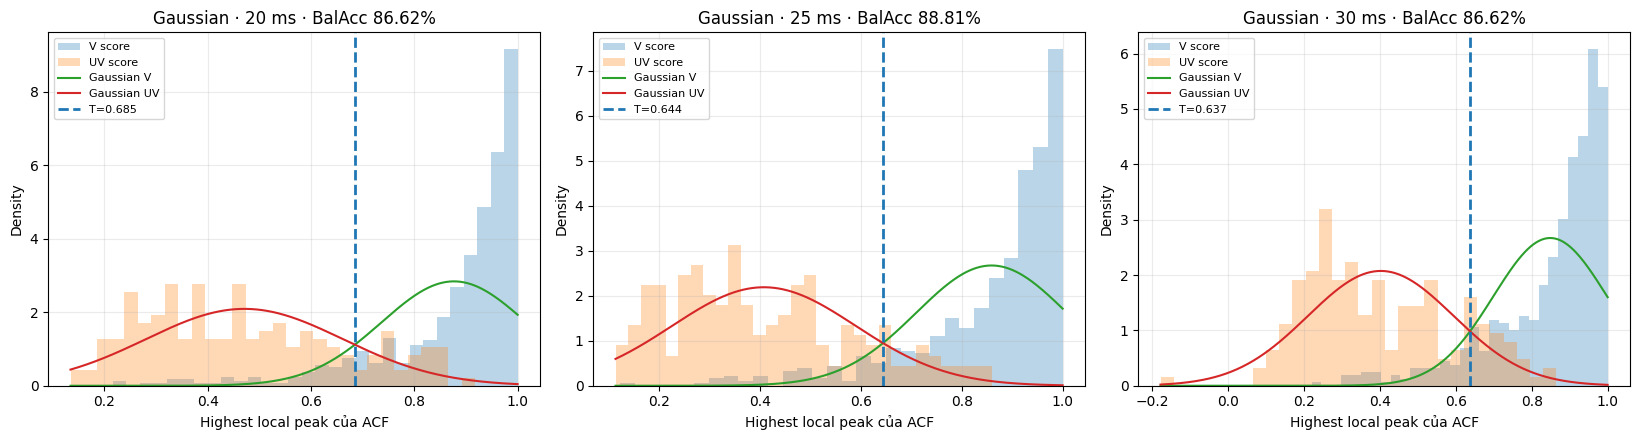

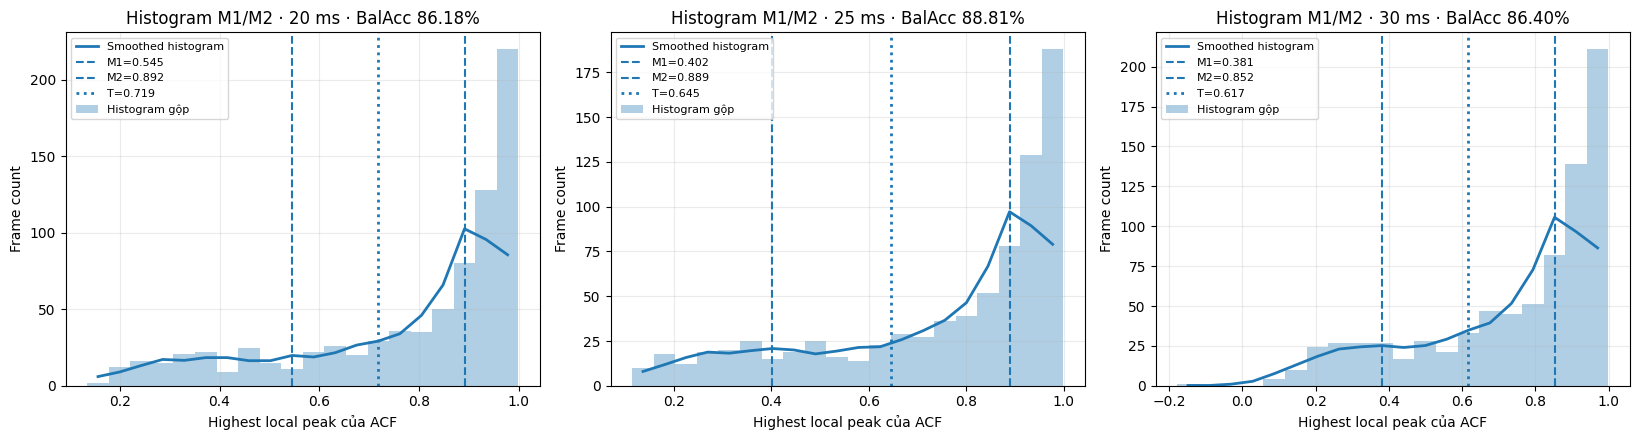

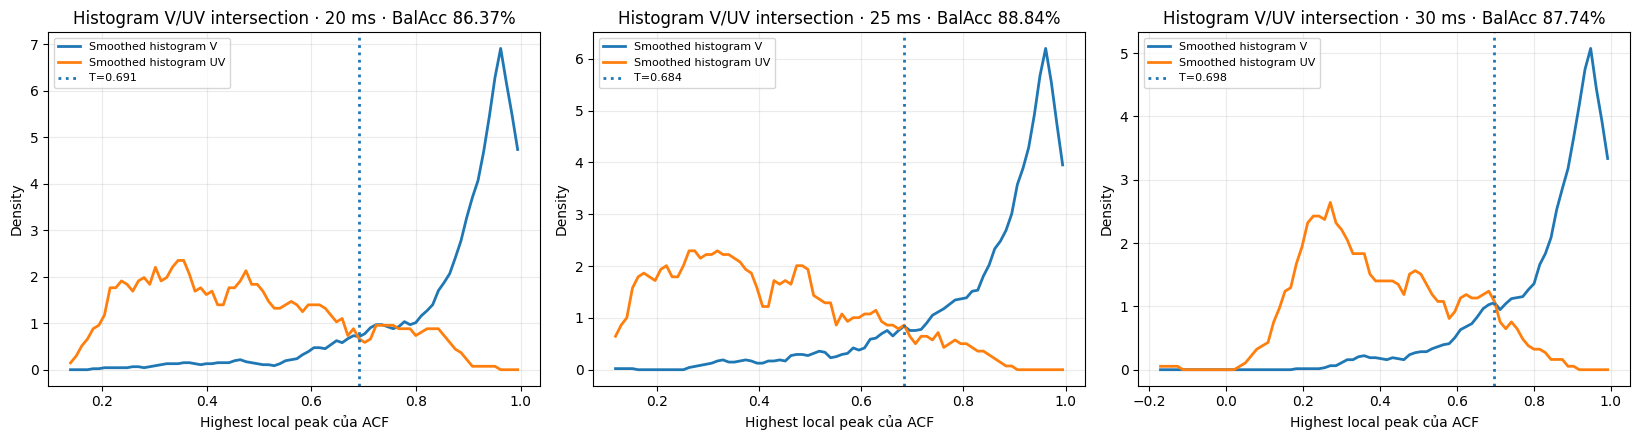

In [109]:
# Ba figure riêng: Gaussian, histogram hai mode, histogram theo nhãn; mỗi figure có 20/25/30 ms.
fig_gaussian, axes_gaussian = plt.subplots(1, len(FRAME_CANDIDATES_MS), figsize=(5.5 * len(FRAME_CANDIDATES_MS), 4.5))
fig_modes, axes_modes = plt.subplots(1, len(FRAME_CANDIDATES_MS), figsize=(5.5 * len(FRAME_CANDIDATES_MS), 4.5))
fig_classes, axes_classes = plt.subplots(1, len(FRAME_CANDIDATES_MS), figsize=(5.5 * len(FRAME_CANDIDATES_MS), 4.5))
axes = np.array([axes_gaussian, axes_modes, axes_classes])

for col, frame_ms in enumerate(FRAME_CANDIDATES_MS):
    model = training_models[frame_ms]
    df, s = model['scores'], model['summary']
    h, c = model['mode_info'], model['class_info']
    v = df.loc[df['label'] == 'v', 'score'].to_numpy()
    u = df.loc[df['label'] == 'uv', 'score'].to_numpy()
    x = np.linspace(min(v.min(), u.min()), max(v.max(), u.max()), 500)

    ax = axes[0, col]
    ax.hist(v, bins=30, density=True, alpha=0.30, label='V score')
    ax.hist(u, bins=30, density=True, alpha=0.30, label='UV score')
    ax.plot(x, gaussian_pdf(x, s['meanV'], s['stdV']), label='Gaussian V')
    ax.plot(x, gaussian_pdf(x, s['meanU'], s['stdU']), label='Gaussian UV')
    ax.axvline(s['threshold_gaussian'], linestyle='--', linewidth=2,
               label=f"T={s['threshold_gaussian']:.3f}")
    ax.set_title(f"Gaussian · {frame_ms} ms · BalAcc {s['balacc_gaussian']:.2%}")
    ax.set_xlabel('Highest local peak của ACF')
    ax.set_ylabel('Density')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

    ax = axes[1, col]
    ax.bar(h['centers'], h['hist'], width=np.diff(h['edges']), alpha=0.35,
           align='center', label='Histogram gộp')
    ax.plot(h['centers'], h['smooth_hist'], linewidth=2, label='Smoothed histogram')
    ax.axvline(s['hist_M1'], linestyle='--', label=f"M1={s['hist_M1']:.3f}")
    ax.axvline(s['hist_M2'], linestyle='--', label=f"M2={s['hist_M2']:.3f}")
    ax.axvline(s['threshold_modes'], linestyle=':', linewidth=2,
               label=f"T={s['threshold_modes']:.3f}")
    ax.set_title(f"Histogram M1/M2 · {frame_ms} ms · BalAcc {s['balacc_modes']:.2%}")
    ax.set_xlabel('Highest local peak của ACF')
    ax.set_ylabel('Frame count')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

    ax = axes[2, col]
    ax.plot(c['x'], c['v'], linewidth=2, label='Smoothed histogram V')
    ax.plot(c['x'], c['u'], linewidth=2, label='Smoothed histogram UV')
    ax.axvline(s['threshold_classes'], linestyle=':', linewidth=2,
               label=f"T={s['threshold_classes']:.3f}")
    ax.set_title(f"Histogram V/UV intersection · {frame_ms} ms · BalAcc {s['balacc_classes']:.2%}")
    ax.set_xlabel('Highest local peak của ACF')
    ax.set_ylabel('Density')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

for fig in (fig_gaussian, fig_modes, fig_classes):
    fig.tight_layout()
plt.show()


### Chọn bộ tham số cuối cùng

Với mỗi frame length, notebook tính ba ngưỡng Gaussian, histogram M1/M2 và giao điểm histogram V/UV. Ngưỡng có **balanced accuracy V/UV** cao nhất trên training được chọn; nếu hòa, dùng accuracy V/UV. Sau đó chọn frame length có balanced accuracy cao nhất. Test chỉ dùng để báo cáo, không dùng để chọn ngưỡng.


In [110]:
best_row = max(
    training_rows,
    key=lambda row: (row['balanced_accuracy'], row['accuracy'])
)
FINAL_FRAME_MS = int(best_row['frame_ms'])
FINAL_THRESHOLD = float(best_row['threshold'])
FINAL_THRESHOLD_METHOD = str(best_row['threshold_method'])
FINAL_TRAIN_METRICS = best_row

selection_rows = []
for row in training_rows:
    selection_rows.append({
        'Frame (ms)': int(row['frame_ms']),
        'Chosen method': row['threshold_method'],
        'Threshold': float(row['threshold']),
        'Accuracy V/UV': float(row['accuracy']),
        'Balanced accuracy V/UV': float(row['balanced_accuracy']),
    })
selection_df = pd.DataFrame(selection_rows)
selection_display = selection_df.copy()
selection_display['Threshold'] = selection_display['Threshold'].map(lambda value: f'{value:.4f}')
for column in ['Accuracy V/UV', 'Balanced accuracy V/UV']:
    selection_display[column] = selection_display[column].map(lambda value: f'{value:.2%}')
print('Chosen method for each frame length:')
display(selection_display)
print(f'Final configuration: frame {FINAL_FRAME_MS} ms; shift {HOP_MS} ms; '
      f'F0 {F0_MIN:.0f}–{F0_MAX:.0f} Hz; threshold {FINAL_THRESHOLD:.4f} '
      f'({FINAL_THRESHOLD_METHOD}); training balanced accuracy '
      f'{FINAL_TRAIN_METRICS["balanced_accuracy"]:.2%}')


Chosen method for each frame length:


,Frame (ms),Chosen method,Threshold,Accuracy V/UV,Balanced accuracy V/UV
0,20,Gaussian,0.6846,88.41%,86.62%
1,25,Histogram V/UV intersection,0.6841,87.91%,88.84%
2,30,Histogram V/UV intersection,0.6978,85.89%,87.74%


Final configuration: frame 25 ms; shift 10 ms; F0 70–400 Hz; threshold 0.6841 (Histogram V/UV intersection); training balanced accuracy 88.84%


## Bước 10 – Minh họa voiced/unvoiced với cả 20 ms, 25 ms và 30 ms

Để khảo sát **ảnh hưởng của độ dài khung** một cách trực quan, notebook dùng **cùng một thời điểm tâm** của tín hiệu cho ba độ dài khung:

- 1 thời điểm nằm trong vùng **voiced**;
- 1 thời điểm nằm trong vùng **unvoiced**.

Các thời điểm là midpoint của segment `v` và `uv` đầu tiên dài ít nhất 50 ms, chọn theo thứ tự tên file/segment `.lab` giống AMDF và độc lập với score. Với mỗi thời điểm, ta trích ba frame **20 ms**, **25 ms** và **30 ms**, rồi vẽ waveform + normalized ACF cạnh nhau. Mỗi frame length sử dụng **threshold riêng đã được chọn trong ba phương pháp Gaussian, histogram M1/M2 và giao điểm histogram V/UV trên training data** của chính frame length đó.

Nhờ vậy có thể quan sát trực tiếp: frame dài hơn có làm peak ACF rõ/ổn định hơn không, score thay đổi thế nào, và quyết định V/U có nhất quán hay không.

- Nếu frame được xác định voiced: peak vượt threshold → lấy best lag → tính `F0 = fs / best_lag`.
- Nếu frame được xác định unvoiced: peak không vượt threshold → **F0 không xác định**.

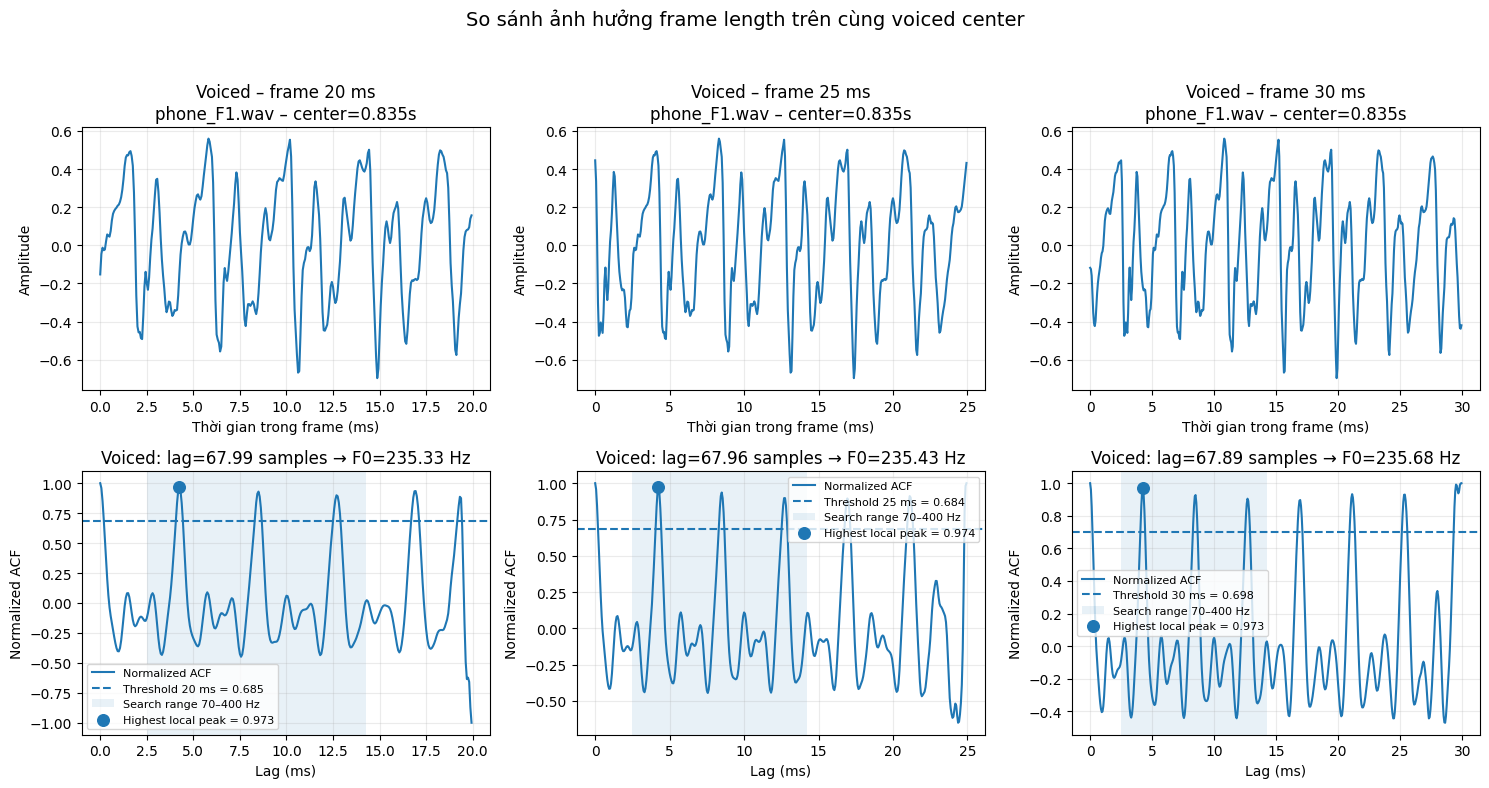

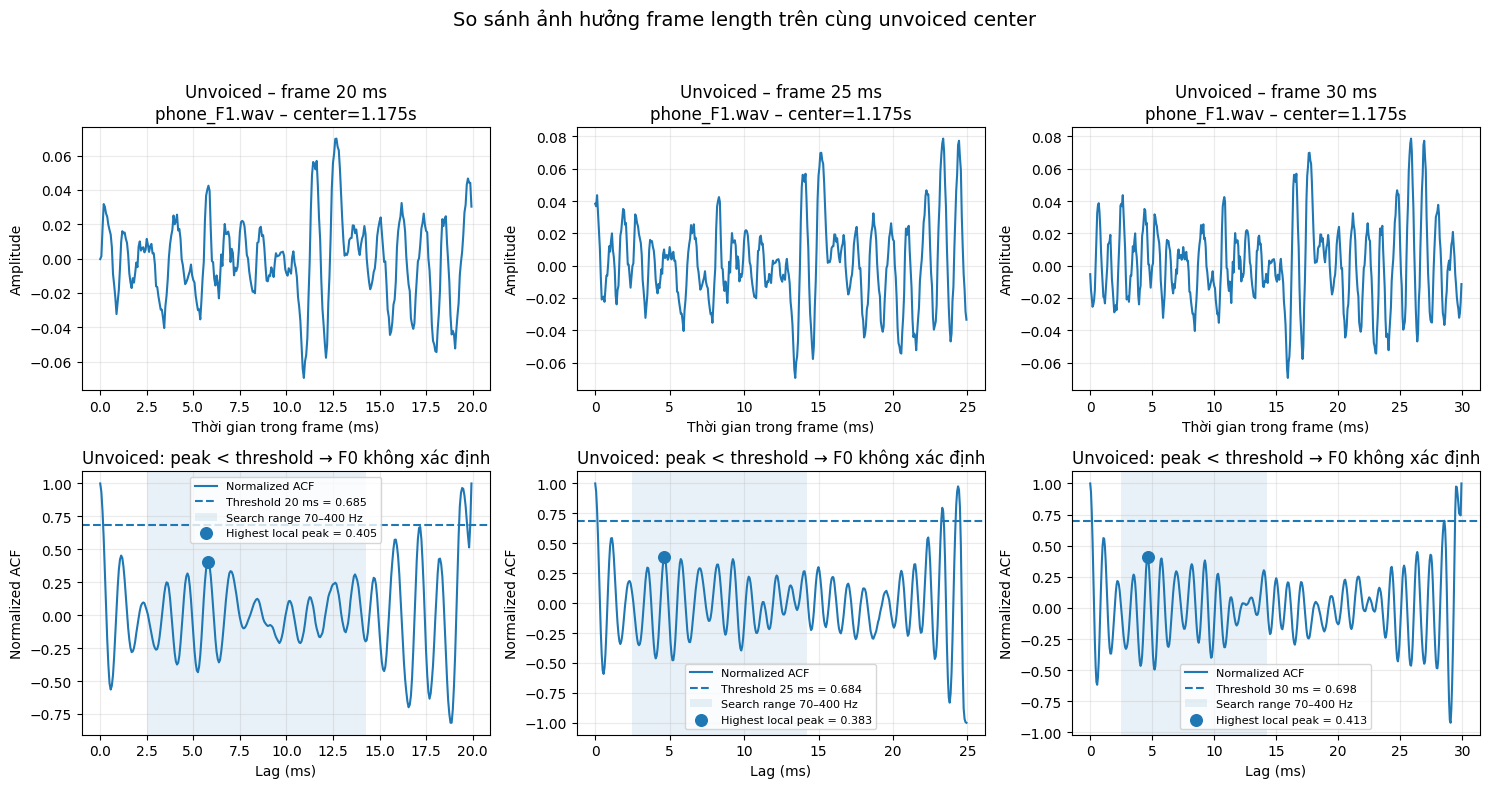

Same-center V/UV examples across frame lengths:


,Example,File,Center (s),GT,Frame (ms),Score,Threshold,Predicted,Best lag (samples),F0 (Hz)
0,Voiced,phone_F1.wav,0.835,v,20,0.9725,0.6846,v,67.9894,235.3310
1,Voiced,phone_F1.wav,0.835,v,25,0.9738,0.6841,v,67.9620,235.4257
2,Voiced,phone_F1.wav,0.835,v,30,0.9726,0.6978,v,67.8879,235.6827
3,Unvoiced,phone_F1.wav,1.175,uv,20,0.4052,0.6846,uv,92.5993,NaN
4,Unvoiced,phone_F1.wav,1.175,uv,25,0.3827,0.6841,uv,74.4255,NaN
5,Unvoiced,phone_F1.wav,1.175,uv,30,0.4126,0.6978,uv,74.0628,NaN


In [111]:
def extract_frame_centered(signal, fs, center_time, frame_ms):
    """Trích frame có đúng center_time để 20 ms, 25 ms và 30 ms so sánh cùng vị trí."""
    frame_len = int(round(fs * frame_ms / 1000.0))
    center_sample = int(round(center_time * fs))
    start = center_sample - frame_len // 2
    start = max(0, min(start, len(signal) - frame_len))
    end = start + frame_len
    return signal[start:end]


# Chọn deterministic cùng một file và segment LAB cho cả ACF/AMDF.
def find_demo_segment(target_label):
    for wav_path in train_wavs:
        segments, _, _ = parse_lab_file(get_lab_path(wav_path))
        for seg in segments:
            if seg['label'] == target_label and seg['end'] - seg['start'] >= 0.05:
                return {
                    'file': os.path.basename(wav_path),
                    'time': 0.5 * (seg['start'] + seg['end']),
                    'label': target_label,
                }
    raise RuntimeError(f'Không tìm thấy segment {target_label} đủ dài để minh họa.')


example_rows = [
    ('Voiced', find_demo_segment('v')),
    ('Unvoiced', find_demo_segment('uv')),
]

comparison_rows = []

for example_name, row in example_rows:
    wav_path = os.path.join(TRAIN_DIR, row['file'])
    fs, signal = load_wav(wav_path)
    t_center = float(row['time'])

    # 2 hàng: waveform, ACF | len(FRAME_CANDIDATES_MS) cột
    fig, axes = plt.subplots(2, len(FRAME_CANDIDATES_MS), figsize=(15, 8))

    for col, frame_ms in enumerate(FRAME_CANDIDATES_MS):
        threshold = training_models[frame_ms]['summary']['threshold']
        frame = extract_frame_centered(signal, fs, t_center, frame_ms)
        score, best_lag, acf = detect_pitch_acf(frame, fs)

        predicted_voiced = score >= threshold
        f0 = lag_to_f0(best_lag, fs) if predicted_voiced else np.nan

        frame_time_ms = np.arange(len(frame)) / fs * 1000.0
        lag_ms = np.arange(len(acf)) / fs * 1000.0
        lag_min = int(np.ceil(fs / F0_MAX))
        lag_max = min(len(frame) - 2, int(np.floor(fs / F0_MIN)))

        # Waveform
        ax_w = axes[0, col]
        ax_w.plot(frame_time_ms, frame)
        ax_w.set_title(
            f"{example_name} – frame {frame_ms} ms\n"
            f"{row['file']} – center={t_center:.3f}s"
        )
        ax_w.set_xlabel('Thời gian trong frame (ms)')
        ax_w.set_ylabel('Amplitude')
        ax_w.grid(alpha=0.25)

        # ACF
        ax_a = axes[1, col]
        ax_a.plot(lag_ms, acf, label='Normalized ACF')
        ax_a.axhline(
            threshold, linestyle='--',
            label=f"Threshold {frame_ms} ms = {threshold:.3f}"
        )
        ax_a.axvspan(
            lag_min / fs * 1000.0,
            lag_max / fs * 1000.0,
            alpha=0.10,
            label='Search range 70–400 Hz'
        )
        ax_a.scatter(
            [best_lag / fs * 1000.0], [score],
            s=70, zorder=3,
            label=f"Highest local peak = {score:.3f}"
        )

        if predicted_voiced:
            ax_a.set_title(
                f"Voiced: lag={best_lag:.2f} samples → F0={f0:.2f} Hz"
            )
        else:
            ax_a.set_title(
                'Unvoiced: peak < threshold → F0 không xác định'
            )

        ax_a.set_xlabel('Lag (ms)')
        ax_a.set_ylabel('Normalized ACF')
        ax_a.grid(alpha=0.25)
        ax_a.legend(fontsize=8)

        comparison_rows.append({
            'example': example_name,
            'file': row['file'],
            'center_s': t_center,
            'ground_truth': row['label'],
            'frame_ms': frame_ms,
            'score': score,
            'threshold': threshold,
            'predicted': 'v' if predicted_voiced else 'uv',
            'best_lag_samples': best_lag,
            'F0_Hz': f0
        })

    fig.suptitle(
        f"So sánh ảnh hưởng frame length trên cùng {example_name.lower()} center",
        fontsize=14
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

comparison_df = pd.DataFrame(comparison_rows)
comparison_display = comparison_df.rename(columns={
    'example': 'Example', 'file': 'File', 'center_s': 'Center (s)',
    'ground_truth': 'GT', 'frame_ms': 'Frame (ms)',
    'score': 'Score', 'threshold': 'Threshold',
    'predicted': 'Predicted', 'best_lag_samples': 'Best lag (samples)',
    'F0_Hz': 'F0 (Hz)',
})[[
    'Example', 'File', 'Center (s)', 'GT', 'Frame (ms)',
    'Score', 'Threshold', 'Predicted', 'Best lag (samples)', 'F0 (Hz)'
]]
print('Same-center V/UV examples across frame lengths:')
display(comparison_display.round(4))



## Bước 11 – Xử lý hoàn chỉnh một file tín hiệu

Quyết định V/U của từng frame:

$$\text{voiced} \iff \text{periodicity_score} \ge T$$

Nếu voiced:

$$F0 = \frac{f_s}{best\_lag}$$

Nếu không voiced: `F0 = NaN`.

Đánh giá hai phạm vi riêng: **Accuracy V/UV** chỉ xét `v`, `uv`; **Accuracy V/UV/SIL** xét thêm `sil` và xem `sil` là không voiced. Chỉ những frame có nhãn hợp lệ mới nằm trong mẫu số. Nhãn lấy tại tâm frame.


In [112]:
def process_wav_file(wav_path, frame_ms=FINAL_FRAME_MS,
                     threshold=FINAL_THRESHOLD, hop_ms=HOP_MS):
    fs, signal = load_wav(wav_path)
    lab_path = get_lab_path(wav_path)
    segments, gt_f0mean, gt_f0std = parse_lab_file(lab_path)

    frames, times = framing(signal, fs, frame_ms, hop_ms)

    scores = []
    best_lags = []
    f0_values = []
    predicted_voiced = []
    gt_labels = []

    for frame, t in zip(frames, times):
        score, best_lag, _ = detect_pitch_acf(frame, fs)
        is_voiced = score >= threshold

        scores.append(score)
        best_lags.append(best_lag)
        predicted_voiced.append(is_voiced)
        f0_values.append(
            lag_to_f0(best_lag, fs) if is_voiced else np.nan
        )
        gt_labels.append(label_at_time(t, segments))

    result = pd.DataFrame({
        'time': times,
        'score': scores,
        'best_lag': best_lags,
        'predicted_voiced': predicted_voiced,
        'f0': f0_values,
        'gt_label': gt_labels
    })

    valid_f0 = result['f0'].dropna().to_numpy()

    est_f0mean = float(np.mean(valid_f0)) if len(valid_f0) else np.nan
    est_f0std = float(np.std(valid_f0)) if len(valid_f0) else np.nan

    labels = result['gt_label'].to_numpy()
    pred_voiced = result['predicted_voiced'].to_numpy(dtype=bool)
    gt_voiced = labels == 'v'
    mask_vu = np.isin(labels, ['v', 'uv'])
    mask_all = np.isin(labels, ['v', 'uv', 'sil'])
    n_vu, n_all = int(mask_vu.sum()), int(mask_all.sum())
    correct_vu = int(np.sum(gt_voiced[mask_vu] == pred_voiced[mask_vu]))
    correct_all = int(np.sum(gt_voiced[mask_all] == pred_voiced[mask_all]))
    accuracy_vu = correct_vu / n_vu if n_vu else np.nan
    accuracy_all = correct_all / n_all if n_all else np.nan

    summary = {
        'file': os.path.basename(wav_path),
        'fs': fs,
        'frame_ms': frame_ms,
        'threshold': threshold,
        'n_frames': len(result),
        'n_predicted_voiced': int(np.sum(pred_voiced)),
        'n_vu': n_vu,
        'correct_vu': correct_vu,
        'accuracy_vu': accuracy_vu,
        'n_all': n_all,
        'correct_all': correct_all,
        'accuracy_all': accuracy_all,
        'sil_false_voiced': int(np.sum((labels == 'sil') & pred_voiced)),
        'F0mean_GT': gt_f0mean,
        'F0mean_est': est_f0mean,
        'abs_error_mean': abs(est_f0mean - gt_f0mean),
        'F0std_GT': gt_f0std,
        'F0std_est': est_f0std,
        'abs_error_std': abs(est_f0std - gt_f0std)
    }

    return signal, fs, segments, result, summary


## Bước 12 – Hàm vẽ input + output cho một test file

Mỗi file test tạo đúng **một figure**:
1. waveform đầu vào + vùng ground truth `v`;
2. estimated F0 contour theo thời gian.

Do `.lab` chỉ cung cấp segment V/UV/SIL và hai thống kê `F0mean/F0std`, không có F0 ground-truth theo từng frame, figure dùng đường ngang `F0mean` và dải `±F0std` để hỗ trợ đối chiếu trực quan.


In [113]:
def plot_test_result(wav_path, signal, fs, segments, result, summary):
    t_signal = np.arange(len(signal)) / fs

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # 1) Input waveform
    axes[0].plot(t_signal, signal, linewidth=0.8)

    # Plot Ground-truth voiced (Màu xanh dương)
    first_v = True
    for seg in segments:
        if seg['label'] == 'v':
            axes[0].axvspan(
                seg['start'], seg['end'],
                color='blue', alpha=0.12,
                label='Ground-truth voiced' if first_v else None
            )
            first_v = False

    # Plot Predicted voiced (Màu xanh lá)
    predicted_times = result['time'].to_numpy()
    pred_voiced = result['predicted_voiced'].to_numpy()
    hop_s = HOP_MS / 1000.0

    in_voiced = False
    start_t = 0
    first_pred = True
    for i in range(len(pred_voiced)):
        if pred_voiced[i] and not in_voiced:
            start_t = predicted_times[i] - hop_s/2
            in_voiced = True
        elif not pred_voiced[i] and in_voiced:
            end_t = predicted_times[i-1] + hop_s/2
            axes[0].axvspan(
                start_t, end_t,
                color='green', alpha=0.25,
                label='Predicted voiced' if first_pred else None
            )
            first_pred = False
            in_voiced = False
    if in_voiced:
        end_t = predicted_times[-1] + hop_s/2
        axes[0].axvspan(
            start_t, end_t,
            color='green', alpha=0.25,
            label='Predicted voiced' if first_pred else None
        )

    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"Input waveform – {os.path.basename(wav_path)}")
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc='upper right')

    # 2) Output F0 contour
    # Bỏ lọc valid đi để giữ lại các khoảng NaN, giúp đồ thị tự đứt nét
    axes[1].plot(
        result['time'],
        result['f0'],
        '.-',
        markersize=3,
        linewidth=1,
        label='Estimated F0 contour'
    )

    gt_mean = summary['F0mean_GT']
    gt_std = summary['F0std_GT']

    axes[1].axhline(
        gt_mean,
        linestyle='--',
        linewidth=1.5,
        label=f"LAB F0mean={gt_mean:.1f} Hz"
    )
    axes[1].axhspan(
        gt_mean - gt_std,
        gt_mean + gt_std,
        alpha=0.10,
        label=f"LAB F0mean ± F0std ({gt_std:.1f} Hz)"
    )

    axes[1].set_ylim(0, F0_MAX + 30)
    axes[1].set_xlabel("Thời gian (s)")
    axes[1].set_ylabel("F0 (Hz)")
    axes[1].set_title(
        f"Output – F0mean={summary['F0mean_est']:.2f} Hz, "
        f"F0std={summary['F0std_est']:.2f} Hz, "
        f"Acc(V/UV)={summary['accuracy_vu']:.2%}, "
        f"Acc(V/UV/SIL)={summary['accuracy_all']:.2%}"
    )
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()


## Bước 13 – Kiểm thử bốn file

Bảng F0 theo từng file có cùng cấu trúc `TEST WAV`, `LAB/Pred F0mean`, `F0mean MAE`, `LAB/Pred F0std`, `F0std MAE`, `NumF0`. Các đại lượng F0 tính bằng Hz; `NumF0` là số khung có F0 dự đoán hữu hạn, hiển thị là số nguyên. Với một cặp thống kê GT/dự đoán trong mỗi file, `MAE` của dòng chính là sai số tuyệt đối. Bảng phân loại tiếp theo báo riêng hai accuracy và số khung tương ứng. Không tô màu các ô.


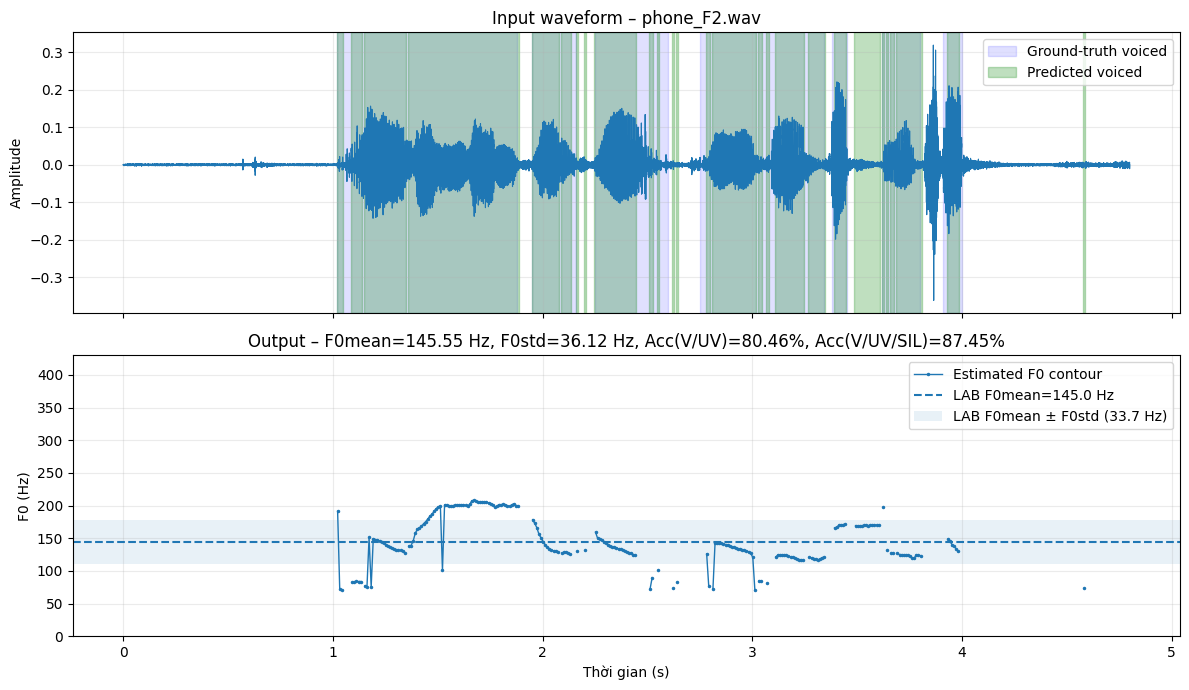

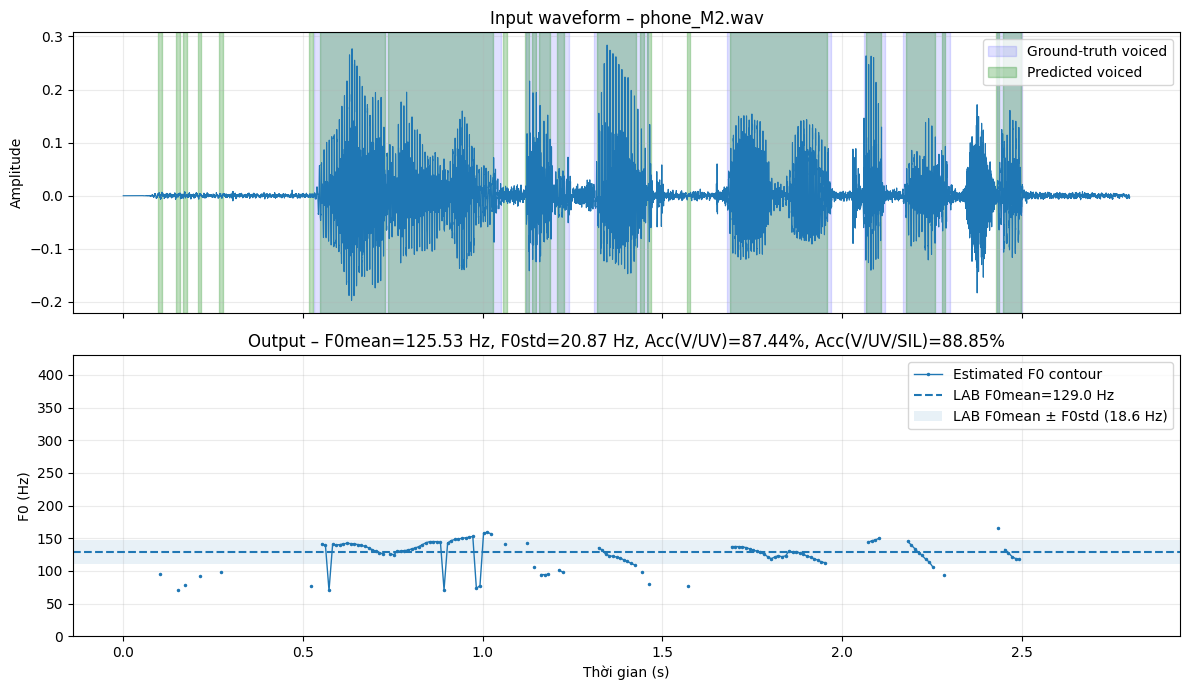

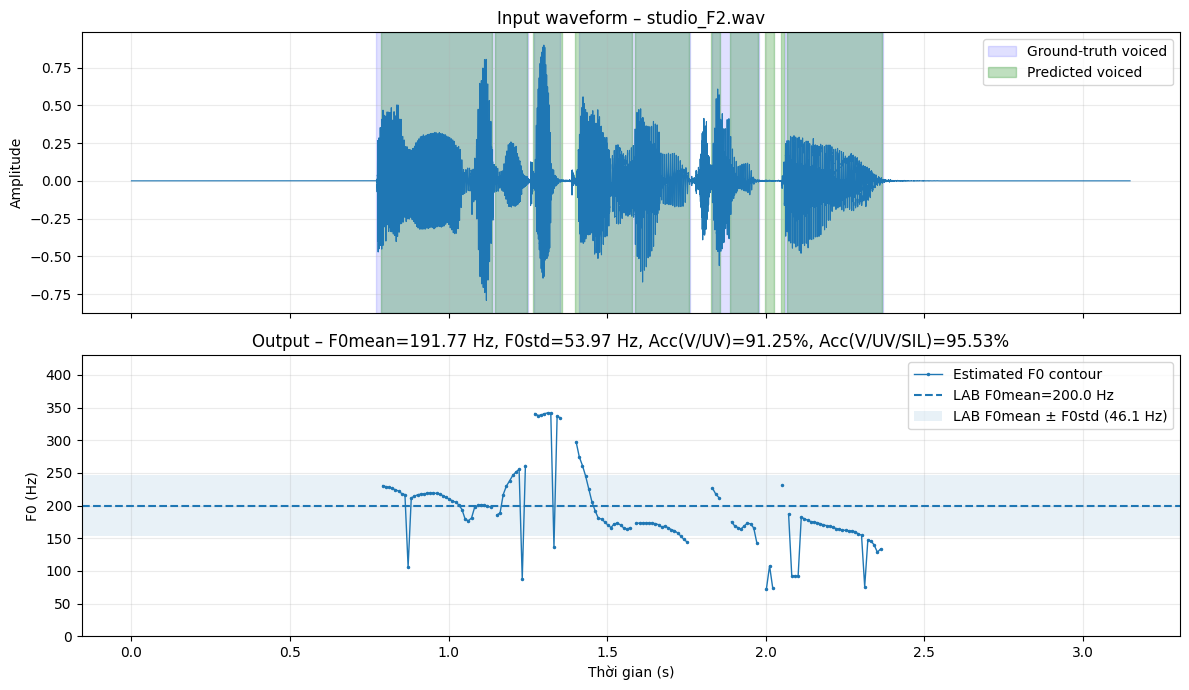

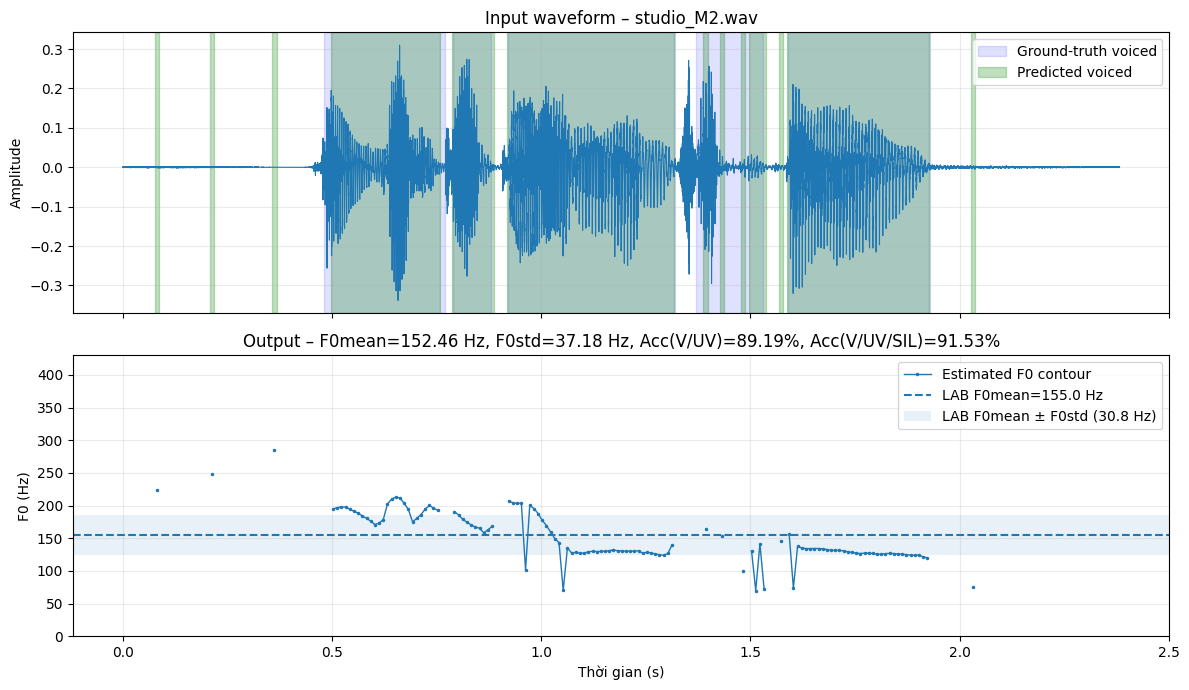

Per-file F0 metrics (all F0 values in Hz; NumF0 is a frame count):


,TEST WAV,LAB F0mean,Pred F0mean,F0mean MAE,LAB F0std,Pred F0std,F0std MAE,NumF0
0,phone_F2.wav,145.0,145.5483,0.5483,33.7,36.1224,2.4224,215
1,phone_M2.wav,129.0,125.5323,3.4677,18.6,20.8747,2.2747,121
2,studio_F2.wav,200.0,191.7749,8.2251,46.1,53.9712,7.8712,135
3,studio_M2.wav,155.0,152.4550,2.5450,30.8,37.1822,6.3822,122


Per-file classification accuracy:


,TEST WAV,Correct V/UV,N V/UV,Accuracy V/UV,Correct V/UV/SIL,N V/UV/SIL,Accuracy V/UV/SIL,False voiced on SIL
0,phone_F2.wav,243,302,80.46%,418,478,87.45%,1
1,phone_M2.wav,174,199,87.44%,247,278,88.85%,6
2,studio_F2.wav,146,160,91.25%,299,313,95.53%,0
3,studio_M2.wav,132,148,89.19%,216,236,91.53%,4


In [114]:
def macro_f1_vu(labels, predictions):
    """Macro F1 của hai lớp V và UV, không dùng SIL."""
    labels = np.asarray(labels)
    predictions = np.asarray(predictions, dtype=bool)
    mask = np.isin(labels, ['v', 'uv'])
    truth = labels[mask] == 'v'
    pred = predictions[mask]
    tp = int(np.sum(truth & pred))
    tn = int(np.sum(~truth & ~pred))
    fp = int(np.sum(~truth & pred))
    fn = int(np.sum(truth & ~pred))
    f1_v = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0
    f1_uv = 2 * tn / (2 * tn + fp + fn) if (2 * tn + fp + fn) else 0.0
    return 0.5 * (f1_v + f1_uv) if mask.any() else np.nan


test_summaries = []
for wav_path in test_wavs:
    signal, fs, segments, result, summary = process_wav_file(wav_path)
    summary['NumF0'] = int(np.isfinite(result['f0'].to_numpy()).sum())
    summary['macro_f1_vu'] = macro_f1_vu(
        result['gt_label'].to_numpy(), result['predicted_voiced'].to_numpy()
    )
    test_summaries.append(summary)
    plot_test_result(wav_path, signal, fs, segments, result, summary)

test_summary_df = pd.DataFrame(test_summaries)

# Mỗi file chỉ có một F0mean/F0std trong LAB, nên MAE ở đây là sai số tuyệt đối của file đó.
f0_report = test_summary_df[[
    'file', 'F0mean_GT', 'F0mean_est', 'abs_error_mean',
    'F0std_GT', 'F0std_est', 'abs_error_std', 'NumF0'
]].rename(columns={
    'file': 'TEST WAV',
    'F0mean_GT': 'LAB F0mean', 'F0mean_est': 'Pred F0mean',
    'abs_error_mean': 'F0mean MAE',
    'F0std_GT': 'LAB F0std', 'F0std_est': 'Pred F0std',
    'abs_error_std': 'F0std MAE'
})
print('Per-file F0 metrics (all F0 values in Hz; NumF0 is a frame count):')
display(f0_report.round(4))

classification_report = test_summary_df[[
    'file', 'correct_vu', 'n_vu', 'accuracy_vu',
    'correct_all', 'n_all', 'accuracy_all', 'sil_false_voiced'
]].rename(columns={
    'file': 'TEST WAV',
    'correct_vu': 'Correct V/UV', 'n_vu': 'N V/UV',
    'accuracy_vu': 'Accuracy V/UV',
    'correct_all': 'Correct V/UV/SIL', 'n_all': 'N V/UV/SIL',
    'accuracy_all': 'Accuracy V/UV/SIL',
    'sil_false_voiced': 'False voiced on SIL'
})
classification_display = classification_report.copy()
for column in ['Accuracy V/UV', 'Accuracy V/UV/SIL']:
    classification_display[column] = classification_display[column].map(
        lambda value: f'{value:.2%}' if pd.notna(value) else '—'
    )
print('Per-file classification accuracy:')
display(classification_display)


## Bước 14 – Tổng kết tự động

MAE, RMSE và MAPE được tính trên bốn cặp thống kê F0 theo file; MAPE bỏ qua GT bằng 0. `Macro F1 (V/UV)` là trung bình F1 của hai lớp `v`, `uv` trong từng file, rồi lấy trung bình không trọng số qua bốn file. Hai macro accuracy được báo ở bảng riêng, cũng là trung bình không trọng số qua các file.


In [115]:
def aggregate_f0_metrics(gt, pred):
    """MAE/RMSE/MAPE trên các thống kê F0 theo file, bỏ giá trị thiếu; MAPE bỏ GT=0."""
    gt = np.asarray(gt, dtype=float)
    pred = np.asarray(pred, dtype=float)
    valid = np.isfinite(gt) & np.isfinite(pred)
    errors = pred[valid] - gt[valid]
    mae = float(np.mean(np.abs(errors))) if len(errors) else np.nan
    rmse = float(np.sqrt(np.mean(errors ** 2))) if len(errors) else np.nan
    valid_pct = valid & (gt != 0)
    mape = (float(np.mean(np.abs((pred[valid_pct] - gt[valid_pct]) / gt[valid_pct])))
            if valid_pct.any() else np.nan)
    return mae, rmse, mape


mean_mae, mean_rmse, mean_mape = aggregate_f0_metrics(
    test_summary_df['F0mean_GT'], test_summary_df['F0mean_est']
)
std_mae, std_rmse, std_mape = aggregate_f0_metrics(
    test_summary_df['F0std_GT'], test_summary_df['F0std_est']
)
f0_aggregate = pd.DataFrame([{
    'files': len(test_summary_df),
    'F0mean MAE': mean_mae, 'F0mean RMSE': mean_rmse,
    'F0mean MAPE': mean_mape,
    'F0std MAE': std_mae, 'F0std RMSE': std_rmse,
    'F0std MAPE': std_mape,
    'Macro F1 (V/UV)': test_summary_df['macro_f1_vu'].mean(),
}])
f0_aggregate_display = f0_aggregate.copy()
for column in ['F0mean MAE', 'F0mean RMSE', 'F0std MAE', 'F0std RMSE', 'Macro F1 (V/UV)']:
    f0_aggregate_display[column] = f0_aggregate_display[column].map(
        lambda value: f'{value:.4f}' if pd.notna(value) else '—'
    )
for column in ['F0mean MAPE', 'F0std MAPE']:
    f0_aggregate_display[column] = f0_aggregate_display[column].map(
        lambda value: f'{value:.2%}' if pd.notna(value) else '—'
    )
print('Aggregate F0 metrics (MAE/RMSE in Hz; MAPE in %; Macro F1 averaged over files):')
display(f0_aggregate_display)

accuracy_aggregate = pd.DataFrame([{
    'files': len(test_summary_df),
    'Macro accuracy V/UV': test_summary_df['accuracy_vu'].mean(),
    'Macro accuracy V/UV/SIL': test_summary_df['accuracy_all'].mean(),
}])
accuracy_aggregate_display = accuracy_aggregate.copy()
for column in ['Macro accuracy V/UV', 'Macro accuracy V/UV/SIL']:
    accuracy_aggregate_display[column] = accuracy_aggregate_display[column].map(
        lambda value: f'{value:.2%}' if pd.notna(value) else '—'
    )
print('Aggregate classification accuracy (unweighted mean over files):')
display(accuracy_aggregate_display)

print(f'ACF configuration: frame {FINAL_FRAME_MS} ms; shift {HOP_MS} ms; '
      f'F0 {F0_MIN:.0f}–{F0_MAX:.0f} Hz; threshold {FINAL_THRESHOLD:.4f} ({FINAL_THRESHOLD_METHOD})')


Aggregate F0 metrics (MAE/RMSE in Hz; MAPE in %; Macro F1 averaged over files):


,files,F0mean MAE,F0mean RMSE,F0mean MAPE,F0std MAE,F0std RMSE,F0std MAPE,Macro F1 (V/UV)
0,4,3.6965,4.6490,2.21%,4.7376,5.3322,14.30%,0.8114


Aggregate classification accuracy (unweighted mean over files):


,files,Macro accuracy V/UV,Macro accuracy V/UV/SIL
0,4,87.08%,90.84%


ACF configuration: frame 25 ms; shift 10 ms; F0 70–400 Hz; threshold 0.6841 (Histogram V/UV intersection)


## Giải thích ngắn để trình bày

**Vì sao ACF giúp tìm F0?**  
Voiced speech gần tuần hoàn. Khi dịch frame đi đúng một chu kỳ \(T_0\), hai phiên bản của tín hiệu giống nhau nhất nên normalized ACF tạo một local peak lớn. Nếu peak đó đủ mạnh để vượt ngưỡng V/U, ta lấy lag tại peak làm chu kỳ và tính \(F0=f_s/lag\).

**Vì sao unvoiced không có F0?**  
Unvoiced speech không có cấu trúc tuần hoàn ổn định. ACF có thể vẫn xuất hiện các peak do nhiễu/ngẫu nhiên, nhưng periodicity score thường thấp hơn phân bố voiced. Nếu highest local peak không vượt threshold được học từ training data, frame được kết luận là unvoiced và F0 không xác định.

**Ảnh hưởng frame length 20 ms vs 25 ms vs 30 ms:**  
Notebook khảo sát theo hai cách: (1) thống kê toàn bộ training data để so sánh `meanV/stdV`, `meanU/stdU`, threshold và balanced accuracy; (2) dùng **cùng một voiced center và cùng một unvoiced center** để vẽ waveform + ACF ở cả 20 ms, 25 ms và 30 ms. Nhờ vậy có thể thấy trực tiếp peak/score/F0 thay đổi thế nào khi chỉ thay độ dài khung.

Frame quá ngắn có ít chu kỳ để ACF quan sát; frame dài hơn thường giúp peak ổn định hơn nhưng có thể kém stationarity. Vì vậy bộ tham số cuối cùng được chọn từ training data chứ không chọn bằng cảm tính.


### Ba phương pháp threshold
Notebook chạy và vẽ riêng Gaussian intersection, histogram hai mode M1/M2 [5] và giao điểm hai histogram V/UV cho 20, 25, 30 ms. Cùng một balanced accuracy V/UV trên training quyết định phương pháp và frame length cuối cùng.
